# Artificial Intelligence Technology and Application

## Machine Learning Lab Guide - Student Version

Independent implementation prepared by **Sundetkhan Bekzat**.


# 1 E-commerce Website User Group Analysis

This notebook keeps the lab objective but uses compact local examples so it can run without external datasets.


## 1.1 Behavioral Features
Users are described by visits, spend, and return rate.


In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(30)
segments = [
    rng.normal([12, 65, 0.05], [3, 12, 0.02], size=(45, 3)),
    rng.normal([4, 18, 0.18], [1, 5, 0.04], size=(45, 3)),
    rng.normal([20, 120, 0.09], [4, 18, 0.03], size=(45, 3)),
]
users = pd.DataFrame(np.vstack(segments), columns=["visits", "spend", "return_rate"])
print(users.head())


      visits      spend  return_rate
0  16.723923  73.919401     0.030602
1  11.363987  61.559241     0.097248
2   9.170324  81.509538     0.052464
3  15.065561  64.966663     0.057855
4  13.473468  66.314464     0.063025


## 1.2 K-Means Segmentation
Clustering groups customers for marketing decisions.


In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaled_users = StandardScaler().fit_transform(users)
kmeans = KMeans(n_clusters=3, random_state=30, n_init=10).fit(scaled_users)
users["cluster"] = kmeans.labels_
print(users.groupby("cluster").mean().round(2))


         visits   spend  return_rate
cluster                             
0         20.24  122.78         0.10
1         12.87   66.61         0.05
2          3.84   18.63         0.18


## 1.3 Elbow Check
Inertia values are printed for a quick model selection check.


In [3]:
inertias = []
for k in range(1, 6):
    inertias.append(KMeans(n_clusters=k, random_state=30, n_init=10).fit(scaled_users).inertia_)
print([round(v, 2) for v in inertias])


[405.0, 143.49, 71.42, 55.58, 46.88]


## 1.4 Segment Plot
Spend and visit frequency provide an interpretable 2D view.


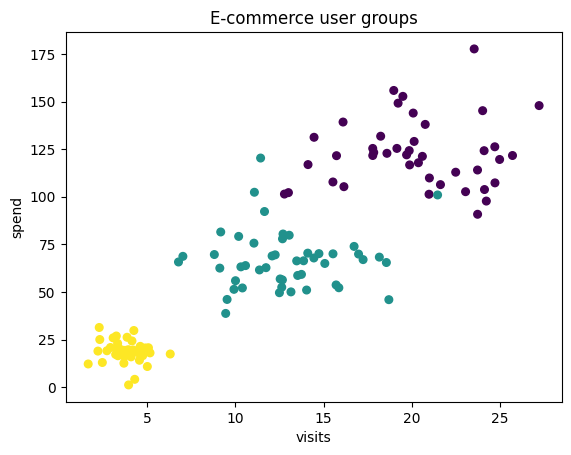

In [4]:
import matplotlib.pyplot as plt

plt.scatter(users["visits"], users["spend"], c=users["cluster"], cmap="viridis", s=30)
plt.xlabel("visits")
plt.ylabel("spend")
plt.title("E-commerce user groups")
plt.show()
